In [2]:
from pipeline_utils import load_and_combine_data, clean_data, create_features, handle_cardinality, prepare_ml_dataframe
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# suppressing warnings for code readability
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Executing the data pipeline

df = load_and_combine_data()
df = clean_data(df)
df = create_features(df)
df = handle_cardinality(df,'brand')

Found 4 files: ['dec_sales.csv', 'nov_sales.csv', 'oct_sales.csv', 'sep_sales.csv']
Successfully loaded dec_sales.csv with 99 rows.
Successfully loaded nov_sales.csv with 101 rows.
Successfully loaded oct_sales.csv with 57 rows.
Successfully loaded sep_sales.csv with 44 rows.

Total rows in combined dataset: 301


# Univariate Analysis


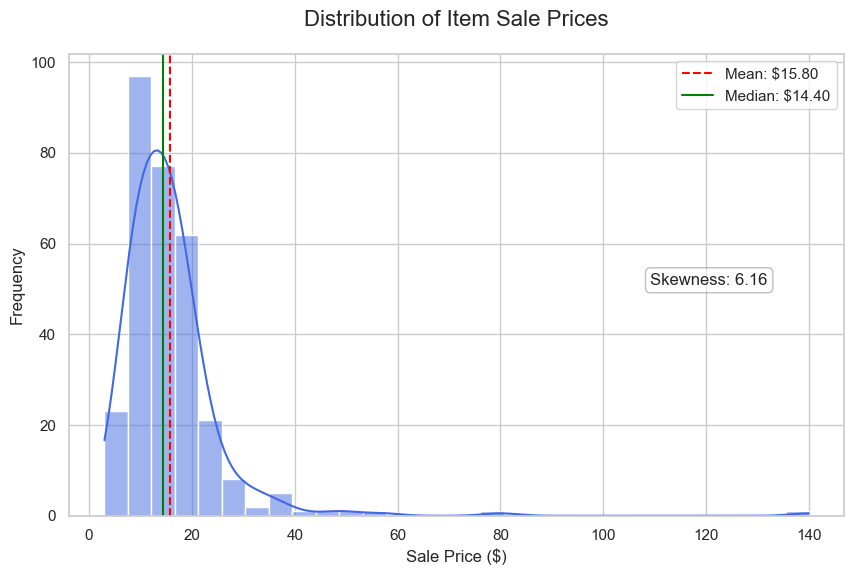

In [4]:
# Price distribution histogram

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

ax = sns.histplot(df['item_price'], kde=True, color='royalblue', bins=30)

# mean and median vertical lines
mean_price = df['item_price'].mean()
median_price = df['item_price'].median()
plt.axvline(mean_price, color='red', linestyle='--', label=f'Mean: ${mean_price:.2f}')
plt.axvline(median_price, color='green', linestyle='-', label=f'Median: ${median_price:.2f}')

# Formatting
plt.title('Distribution of Item Sale Prices', fontsize=16, pad=20)
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# skewness annotation
skewness = df['item_price'].skew()
plt.annotate(f'Skewness: {skewness:.2f}', xy=(0.75, 0.5), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.5))

plt.show()




The mean ($15.80) is higher than the Median ($14.40), so the distribution is right skewed.

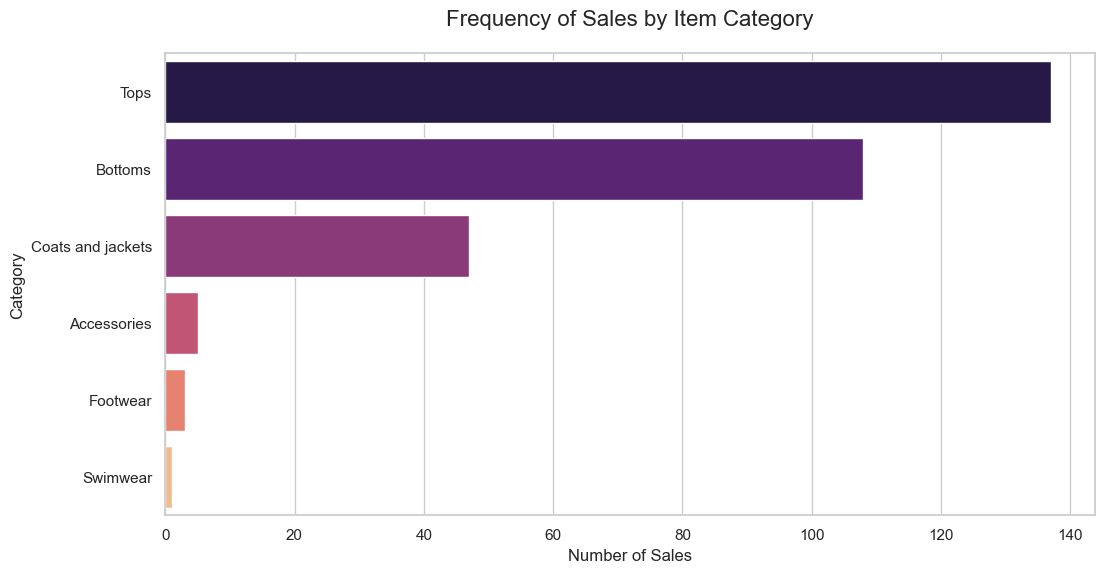

In [6]:


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Calculate frequencies and order them
cat_order = df['category'].value_counts().index

# Create the countplot
sns.countplot(
    data=df,
    y='category',
    order=cat_order,
    palette='magma'
)

# Formatting
plt.title('Frequency of Sales by Item Category', fontsize=16, pad=20)
plt.xlabel('Number of Sales', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.show()

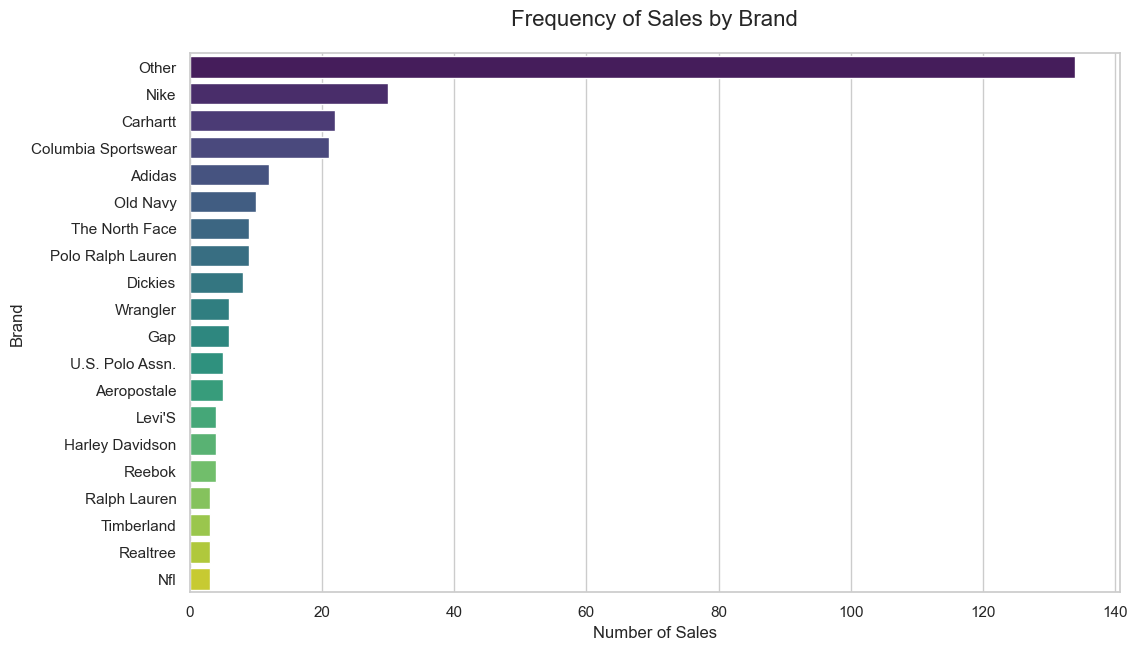

In [7]:


sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Calculate frequencies and order them
brand_order = df['brand'].value_counts().index

# Create the countplot
sns.countplot(
    data=df,
    y='brand',
    order=brand_order,
    palette='viridis'
)

# Formatting
plt.title('Frequency of Sales by Brand', fontsize=16, pad=20)
plt.xlabel('Number of Sales', fontsize=12)
plt.ylabel('Brand', fontsize=12)

plt.show()

# Bivariate Analysis

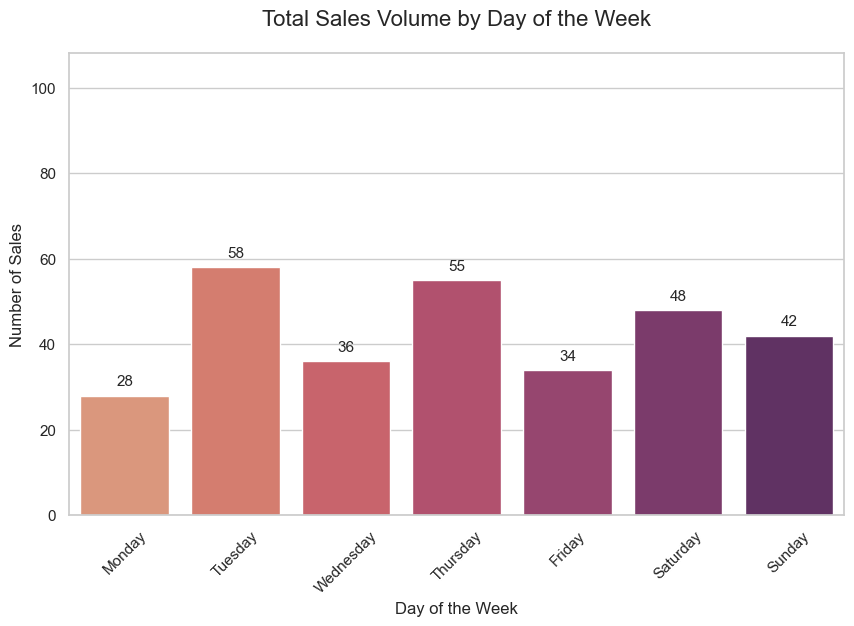

In [8]:


# Define the correct chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))

# Create the countplot
ax = sns.countplot(
    data=df, 
    x='day_posted', 
    order=days_order, 
    palette='flare'
)

# count labels on top of the bars 
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11)

# Formatting
plt.title('Total Sales Volume by Day of the Week', fontsize=16, pad=20)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Sales', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, df['day_posted'].value_counts().max() + 50) # Give some head room for labels

plt.show()

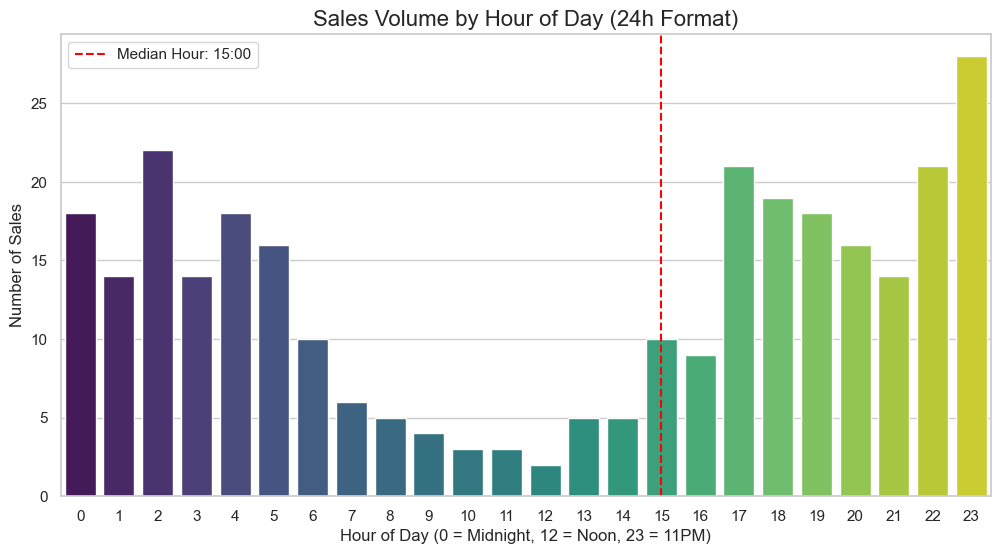

In [9]:


plt.figure(figsize=(12, 6))

# Create a countplot for hours 0-23
sns.countplot(data=df, x='hour_sold', palette='viridis')

# Add a vertical line for the median hour to show peak
median_hour = df['hour_sold'].median()
plt.axvline(median_hour, color='red', linestyle='--', label=f'Median Hour: {int(median_hour)}:00')

# Formatting
plt.title('Sales Volume by Hour of Day (24h Format)', fontsize=16)
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon, 23 = 11PM)', fontsize=12)
plt.ylabel('Number of Sales', fontsize=12)
plt.xticks(range(0, 24)) # every hour is shown
plt.legend()

plt.show()

<Figure size 1000x500 with 0 Axes>

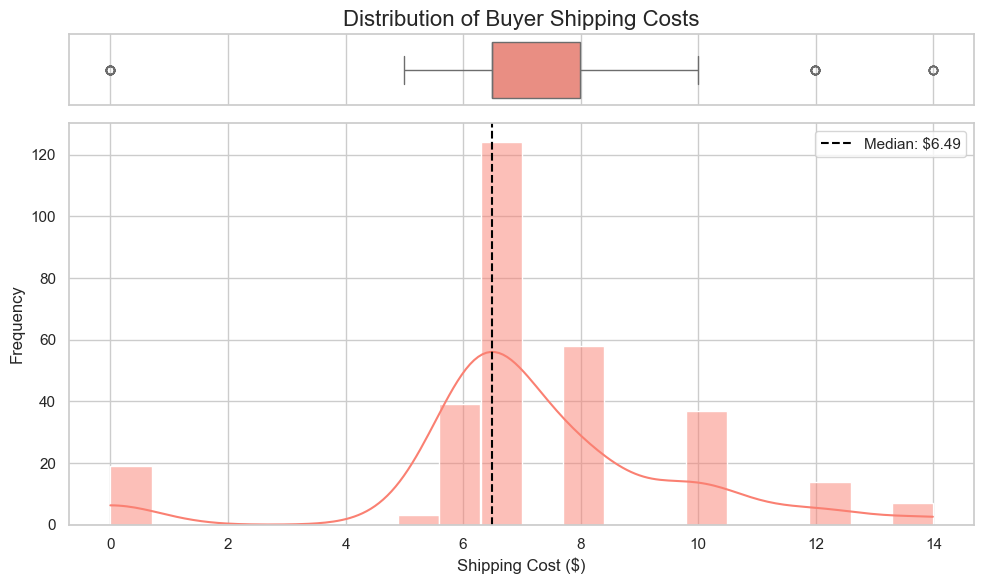

Percentage of items sold with Free Shipping: 6.31%


In [11]:


sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# combined plot: Boxplot on top of a Histogram

f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

# Add Boxplot
sns.boxplot(x=df['buyer_shipping_cost'], ax=ax_box, color='salmon')
ax_box.set(xlabel='') # Remove x-label for the top box
ax_box.set_title('Distribution of Buyer Shipping Costs', fontsize=16)

# Add Histogram
sns.histplot(x=df['buyer_shipping_cost'], ax=ax_hist, kde=True, color='salmon', bins=20)

# Add vertical line for the median
median_ship = df['buyer_shipping_cost'].median()
plt.axvline(median_ship, color='black', linestyle='--', label=f'Median: ${median_ship:.2f}')

# Formatting
plt.xlabel('Shipping Cost ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

free_shipping_pct = (df['buyer_shipping_cost'] == 0).mean() * 100
print(f"Percentage of items sold with Free Shipping: {free_shipping_pct:.2f}%")

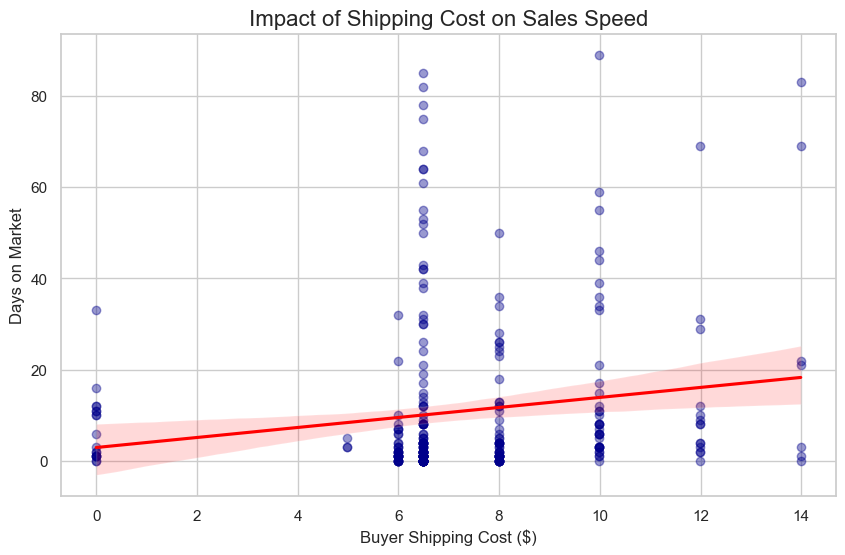

Correlation between Shipping Cost and Days to Sell: 0.16
For every $1 saved in shipping, items sell approximately 1.10 days faster.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# scatter plot with a trend line
sns.regplot(data=df, x='buyer_shipping_cost', y='days_to_sell', 
            scatter_kws={'alpha':0.4, 'color':'darkblue'}, 
            line_kws={'color':'red'})

plt.title('Impact of Shipping Cost on Sales Speed', fontsize=16)
plt.xlabel('Buyer Shipping Cost ($)', fontsize=12)
plt.ylabel('Days on Market', fontsize=12)

plt.show()


ship_corr = df['buyer_shipping_cost'].corr(df['days_to_sell'])
print(f"Correlation between Shipping Cost and Days to Sell: {ship_corr:.2f}")

m, b = np.polyfit(df['buyer_shipping_cost'], df['days_to_sell'], 1)
print(f"For every $1 saved in shipping, items sell approximately {abs(m):.2f} days faster.")

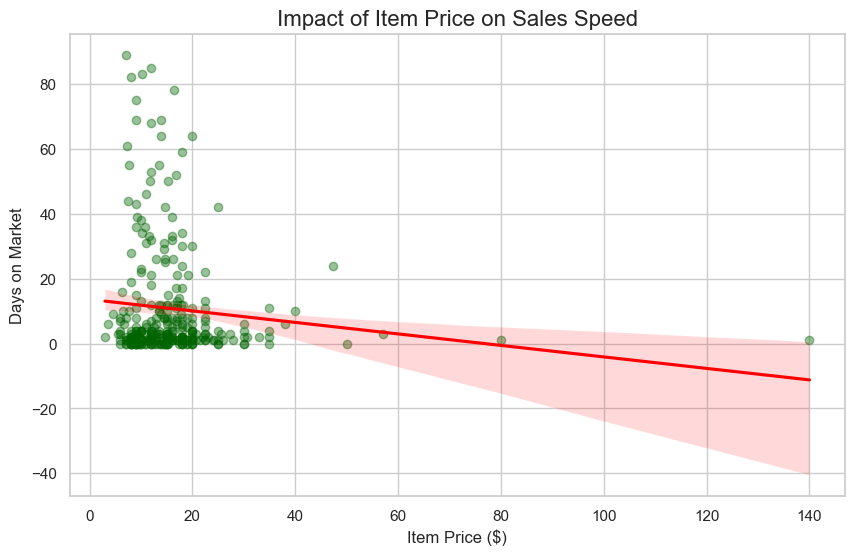

For every $1 saved in item cost, items sell approximately 0.18 days faster.


In [13]:

plt.figure(figsize=(10, 6))

# Regression plot for Price vs Speed
sns.regplot(
    data=df, 
    x='item_price', 
    y='days_to_sell', 
    scatter_kws={'alpha': 0.4, 'color': 'darkgreen'}, 
    line_kws={'color': 'red'}
)

plt.title('Impact of Item Price on Sales Speed', fontsize=16)
plt.xlabel('Item Price ($)', fontsize=12)
plt.ylabel('Days on Market', fontsize=12)

plt.show()

m, b = np.polyfit(df['item_price'], df['days_to_sell'], 1)
print(f"For every $1 saved in item cost, items sell approximately {abs(m):.2f} days faster.")

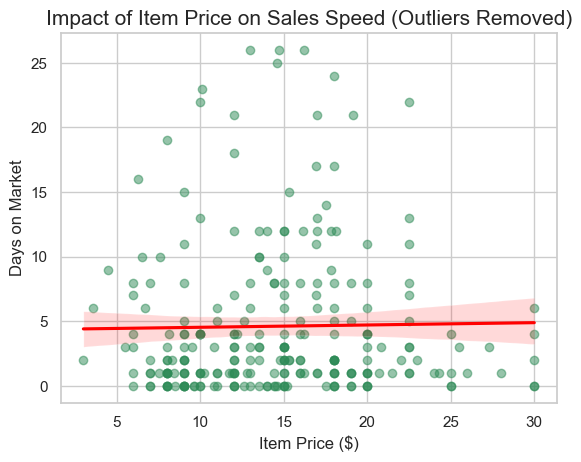

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

#filter item price outliers
q1_price = df['item_price'].quantile(0.25)
q3_price = df['item_price'].quantile(0.75)
iqr_price = q3_price - q1_price
price_upper = q3_price + 1.5 * iqr_price

#filter days to sell outliers 
q1_days = df['days_to_sell'].quantile(0.25)
q3_days = df['days_to_sell'].quantile(0.75)
iqr_days = q3_days - q1_days
days_upper = q3_days + 1.5 * iqr_days


df_filtered = df[(df['item_price'] <= price_upper) & (df['days_to_sell'] <= days_upper)]

# generate plot
sns.set_theme(style="whitegrid")
sns.regplot(
    data=df_filtered, 
    x='item_price', 
    y='days_to_sell', 
    scatter_kws={'alpha': 0.5, 'color': 'seagreen'}, 
    line_kws={'color': 'red'}
)

# Formatting
plt.title('Impact of Item Price on Sales Speed (Outliers Removed)', fontsize=15)
plt.xlabel('Item Price ($)', fontsize=12)
plt.ylabel('Days on Market', fontsize=12)

plt.savefig('price_vs_speed_no_outliers.png')

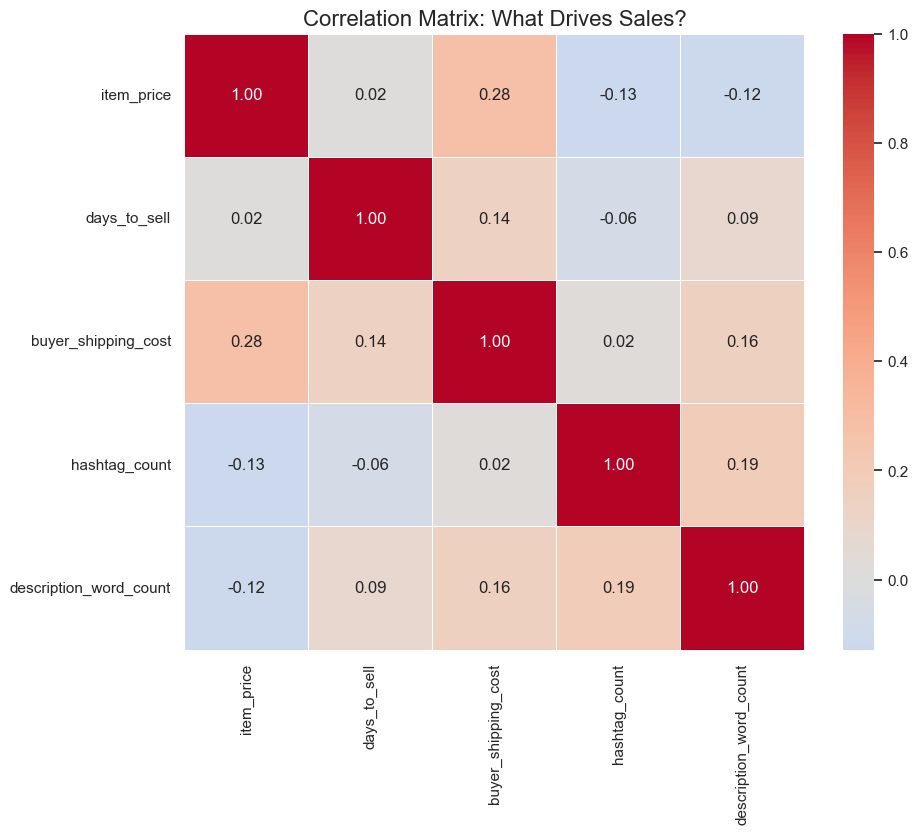

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# select only the relevant numerical features
# filtered data so outliers dont warp correlations
cols = ['item_price', 'days_to_sell', 'buyer_shipping_cost', 
        'hashtag_count', 'description_word_count']

# Calculate the correlation matrix
corr_matrix = df_filtered[cols].corr()

# Create the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    center=0,
    linewidths=0.5
)

plt.title('Correlation Matrix: What Drives Sales?', fontsize=16)
plt.show()